<a href="https://colab.research.google.com/github/Shivam-1812/AI-ML-Labs/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Required Libraries for student prediction

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Create Dataset**

In [5]:
data = {
    "study_hours": [1,2,3,4,5,6,7,8,2.5,3.5],
    "attendance": [75,80,85,88,90,92,95,96,78,84],
    "sleep_hours": [8,7,7,6,6,6,5,5,8,7],
    "previous_score": [50,55,65,70,75,80,85,90,60,68],
    "final_score": [52,60,68,75,82,88,93,96,65,72]
}


import pandas as pd
df = pd.DataFrame(data)
df.head()

,study_hours,attendance,sleep_hours,previous_score,final_score
0,1.0,75,8,50,52
1,2.0,80,7,55,60
2,3.0,85,7,65,68
3,4.0,88,6,70,75
4,5.0,90,6,75,82


**Basic Data Understanding**

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     10 non-null     float64
 1   attendance      10 non-null     int64  
 2   sleep_hours     10 non-null     int64  
 3   previous_score  10 non-null     int64  
 4   final_score     10 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 532.0 bytes


,study_hours,attendance,sleep_hours,previous_score,final_score
count,10.000000,10.000000,10.000000,10.000000,10.00000
mean,4.200000,86.300000,6.500000,69.800000,75.10000
std,2.263233,7.165504,1.080123,12.925427,14.51015
min,1.000000,75.000000,5.000000,50.000000,52.00000
25%,2.625000,81.000000,6.000000,61.250000,65.75000
50%,3.750000,86.500000,6.500000,69.000000,73.50000
75%,5.750000,91.500000,7.000000,78.750000,86.50000
max,8.000000,96.000000,8.000000,90.000000,96.00000


Check correlation:

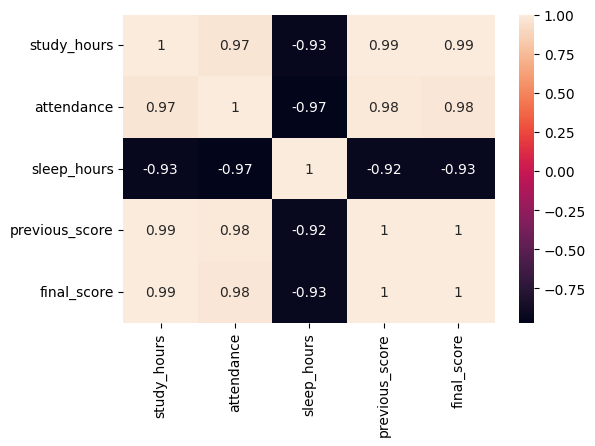

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True)
plt.show()

Prepare Data

In [7]:
X = df.drop("final_score", axis=1)
y = df["final_score"]

Split:

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scale:

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Train Model**

Linear **Regression**

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Predict

In [11]:
y_pred = model.predict(X_test)

Evaluate Model

If R² is close to 1 → good model.

In [12]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.0032733224222667
MSE: 4.833414842309138
R2 Score: 0.2266536252305379


Try Other Models (Important for Learning)

Decision Tree

In [13]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, dt_pred))

Decision Tree R2: -4.84


Random Forest

Compare which performs better.

In [14]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest R2: -1.4615200000000041


Save Model

In [15]:
import joblib
joblib.dump(model, "student_model.pkl")

['student_model.pkl']